# Análise de Sentimentos em Dados do Twitter

Este projeto tem como objetivo realizar a análise de sentimentos em uma base de dados de tweets. O fluxo de trabalho abrange desde o carregamento dos dados e análise exploratória até o pré-processamento de texto e vetorização para preparação de modelos de aprendizado de máquina.

In [57]:
import sys
sys.path.append("../../../src")


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata

from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import KFold
from imblearn.under_sampling import RandomUnderSampler

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


from sklearn.metrics import  confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from wordcloud import WordCloud
from spacy.lang.pt.stop_words import STOP_WORDS
from scipy.stats import wilcoxon
import plotar_graficos as pg
import experimentos as exp
import pre_processamento as pp
import pnl_utils as pnl


In [38]:
base_twitter = pd.read_csv('../../../data/raw/Twitter_atualizado.csv', low_memory=False)
base_twitter

,id,tweet_text,tweet_date,sentiment,query_used
0,1050785521201541121,@Laranjito76 A pessoa certa para isso seria o ...,Fri Oct 12 16:29:25 +0000 2018,1,:)
1,1050785431955140608,"@behin_d_curtain Para mim, é precisamente o co...",Fri Oct 12 16:29:04 +0000 2018,1,:)
2,1050785401248645120,Vou fazer um video hoje... estou pensando em f...,Fri Oct 12 16:28:56 +0000 2018,1,:)
3,1050785370982547461,"aaaaaaaa amei tanto essas polaroids, nem sei e...",Fri Oct 12 16:28:49 +0000 2018,1,:)
4,1050785368902131713,Valoriza o coração do menininho que vc tem. El...,Fri Oct 12 16:28:49 +0000 2018,1,:)
...,...,...,...,...,...
19995,1049142031405203457,Como foi o melhor sonho que você já teve? — ci...,Mon Oct 08 03:38:47 +0000 2018,0,:(
19996,1049142030809649153,Tem coisa pior do que ver uma familia apoiando...,Mon Oct 08 03:38:46 +0000 2018,0,:(
19997,1049142017887035392,"@klingersmorais Horrível, bb :(",Mon Oct 08 03:38:43 +0000 2018,0,:(
19998,1049142002879741952,@Omenevivo Vc quer ir pra BH?? E a cidade semp...,Mon Oct 08 03:38:40 +0000 2018,0,:(


In [39]:
base_twitter = base_twitter.drop(['id', 'tweet_date', 'query_used'], axis=1)
base_twitter

,tweet_text,sentiment
0,@Laranjito76 A pessoa certa para isso seria o ...,1
1,"@behin_d_curtain Para mim, é precisamente o co...",1
2,Vou fazer um video hoje... estou pensando em f...,1
3,"aaaaaaaa amei tanto essas polaroids, nem sei e...",1
4,Valoriza o coração do menininho que vc tem. El...,1
...,...,...
19995,Como foi o melhor sonho que você já teve? — ci...,0
19996,Tem coisa pior do que ver uma familia apoiando...,0
19997,"@klingersmorais Horrível, bb :(",0
19998,@Omenevivo Vc quer ir pra BH?? E a cidade semp...,0


In [40]:
base_twitter.isnull().sum()

tweet_text    0
sentiment     0
dtype: int64

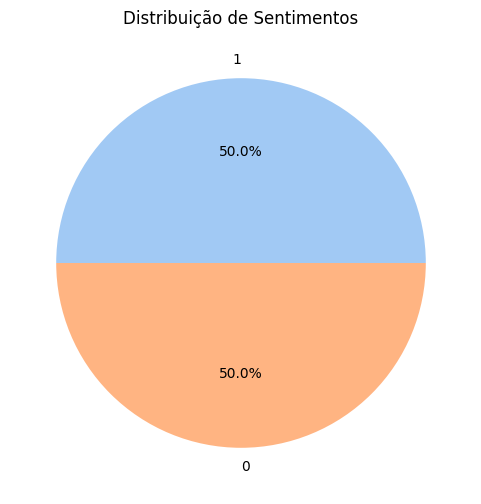

In [41]:
pg.plot_pizza_sentimentos(base_twitter, coluna="sentiment")


In [42]:
base_twitter

,tweet_text,sentiment
0,@Laranjito76 A pessoa certa para isso seria o ...,1
1,"@behin_d_curtain Para mim, é precisamente o co...",1
2,Vou fazer um video hoje... estou pensando em f...,1
3,"aaaaaaaa amei tanto essas polaroids, nem sei e...",1
4,Valoriza o coração do menininho que vc tem. El...,1
...,...,...
19995,Como foi o melhor sonho que você já teve? — ci...,0
19996,Tem coisa pior do que ver uma familia apoiando...,0
19997,"@klingersmorais Horrível, bb :(",0
19998,@Omenevivo Vc quer ir pra BH?? E a cidade semp...,0


In [43]:
stop_words = STOP_WORDS

len(stop_words)

416

In [44]:
base_twitter.head(10)

,tweet_text,sentiment
0,@Laranjito76 A pessoa certa para isso seria o ...,1
1,"@behin_d_curtain Para mim, é precisamente o co...",1
2,Vou fazer um video hoje... estou pensando em f...,1
3,"aaaaaaaa amei tanto essas polaroids, nem sei e...",1
4,Valoriza o coração do menininho que vc tem. El...,1
5,@KingJokerLeto mas amiga eu to aqui ainda :),1
6,"@RivasJairo Bravo, Jairo!!! :)))",1
7,@inquilinasls @Spotify socorro ksoaksosks acho...,1
8,"@chimekarlla gosto muito de fazenda :) , mas m...",1
9,Amanha vou ver venom :D,1


In [45]:
stop_words

{'a',
 'acerca',
 'ademais',
 'adeus',
 'agora',
 'ainda',
 'algo',
 'algumas',
 'alguns',
 'ali',
 'além',
 'ambas',
 'ambos',
 'antes',
 'ao',
 'aos',
 'apenas',
 'apoia',
 'apoio',
 'apontar',
 'após',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aqui',
 'aquilo',
 'as',
 'assim',
 'através',
 'atrás',
 'até',
 'aí',
 'baixo',
 'bastante',
 'bem',
 'boa',
 'bom',
 'breve',
 'cada',
 'caminho',
 'catorze',
 'cedo',
 'cento',
 'certamente',
 'certeza',
 'cima',
 'cinco',
 'coisa',
 'com',
 'como',
 'comprida',
 'comprido',
 'conhecida',
 'conhecido',
 'conselho',
 'contra',
 'contudo',
 'corrente',
 'cuja',
 'cujo',
 'custa',
 'cá',
 'da',
 'daquela',
 'daquele',
 'dar',
 'das',
 'de',
 'debaixo',
 'demais',
 'dentro',
 'depois',
 'des',
 'desde',
 'dessa',
 'desse',
 'desta',
 'deste',
 'deve',
 'devem',
 'deverá',
 'dez',
 'dezanove',
 'dezasseis',
 'dezassete',
 'dezoito',
 'diante',
 'direita',
 'disso',
 'diz',
 'dizem',
 'dizer',
 'do',
 'dois',
 'dos',
 'doze',
 'duas',
 'dá

In [46]:
base_twitter["tweet_text"] = base_twitter["tweet_text"].apply(pnl.clean_tweet)

In [47]:
base_twitter

,tweet_text,sentiment
0,certa vale azevedo,1
1,mim precisamente contrário chuva disposição,1
2,video pensando meta csgo pagina alguem sugesta...,1
3,aaaaaaaa amei polaroids expressar apaixonada v...,1
4,valoriza coração menininho diferente faça sorr...,1
...,...,...
19995,melhor sonho ciro presidente,0
19996,pior familia apoiando bozonaro,0
19997,horrível,0
19998,bh cidade mto receptiva mim,0


### 5.1 Análise de Comprimento das Mensagens
Visualização da variação do tamanho dos tweets após a limpeza para entender a densidade de informações por mensagem.

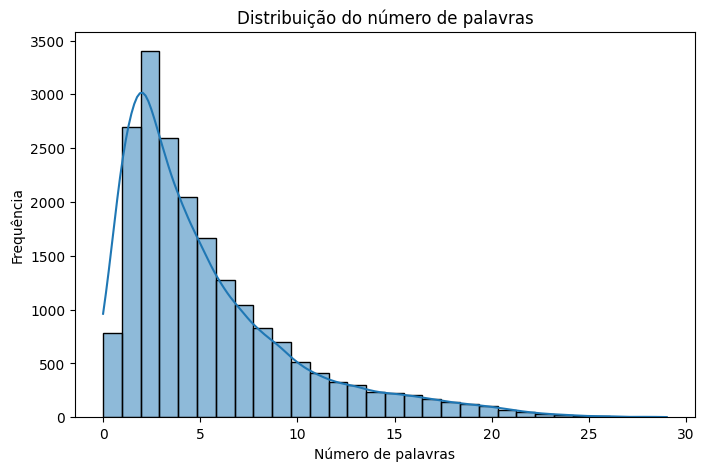

In [48]:
pg.plot_histograma_comprimento_texto(base_twitter, coluna_texto="tweet_text")


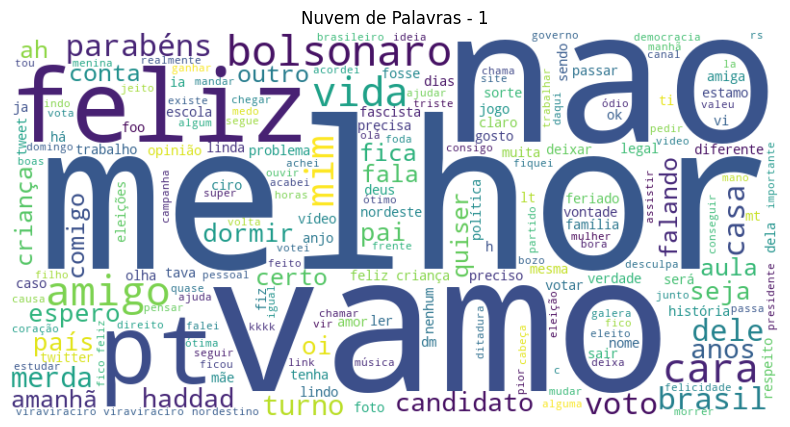

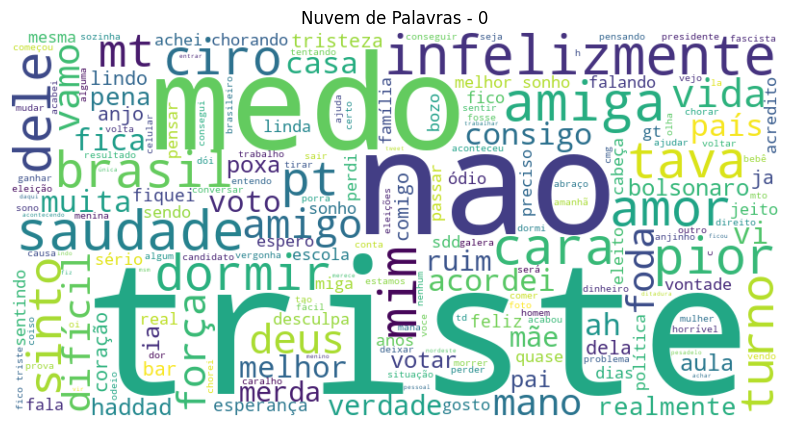

In [49]:
pg.plot_wordcloud_por_categoria(base_twitter, coluna_texto="tweet_text", coluna_categoria="sentiment")


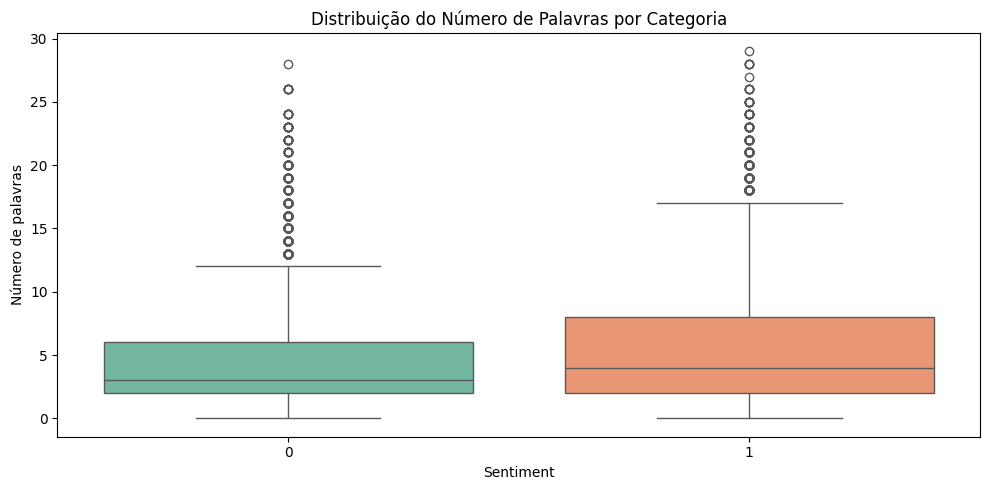

In [50]:
pg.plot_boxplot_comprimento_por_categoria(
    df=base_twitter, 
    coluna_texto="tweet_text", 
    coluna_categoria="sentiment"
)

### Aplicação de TF-IDF e Bag of Words 

In [51]:
vetorizadores_config = {
    "Bag of Words": [
        {"ngram_range": (1, 1), "min_df": 5, "max_df": 0.9},
        {"ngram_range": (1, 2), "min_df": 5, "max_df": 0.9}
    ],
    "TF-IDF": [
        {"ngram_range": (1, 1), "min_df": 2, "sublinear_tf": False, "max_features": 10000},
        {"ngram_range": (1, 2), "min_df": 2, "sublinear_tf": True, "max_features": 10000}
    ]
}

resultados_gerais = pnl.executar_experimentos_texto_com_parametros(
    textos=base_twitter['tweet_text'],
    y=base_twitter['sentiment'],
    funcao_treino=pnl.kfold_gridsearch_classificacao,
    vetorizadores_config=vetorizadores_config
)



===== Fold 1 =====
DT | Melhor F1 (val): 0.6943 | Params: {'class_weight': 'balanced', 'max_depth': 10}
LR | Melhor F1 (val): 0.7307 | Params: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'lbfgs'}
RF | Melhor F1 (val): 0.7176 | Params: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 100}
SVM | Melhor F1 (val): 0.7338 | Params: {'C': 0.1, 'class_weight': 'balanced', 'kernel': 'linear'}

===== Fold 2 =====
DT | Melhor F1 (val): 0.6907 | Params: {'class_weight': 'balanced', 'max_depth': 10}
LR | Melhor F1 (val): 0.7135 | Params: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'lbfgs'}
RF | Melhor F1 (val): 0.7115 | Params: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 100}
SVM | Melhor F1 (val): 0.7110 | Params: {'C': 0.1, 'class_weight': 'balanced', 'kernel': 'linear'}

===== Fold 3 =====
DT | Melhor F1 (val): 0.6946 | Params: {'class_weight': 'balanced', 'max_depth': 10}
LR | Melhor F1 (val): 0.7271 | Params: {'C': 

In [52]:
df_resultados = pnl.resultados_para_dataframe(resultados_gerais)
df_resultados['configuracao'] = df_resultados['configuracao'].str.split('|').str[-1].str.strip()
df_resultados.to_csv("resultados_pnl.csv", index=False)

df_resultados.head()


,tecnica,model,fold,accuracy,precision,recall,f1,best_params,configuracao
0,Bag of Words,DT,1,0.56600,0.535948,0.9840,0.693935,"{'class_weight': 'balanced', 'max_depth': 10}","{'ngram_range': (1, 1), 'min_df': 5, 'max_df':..."
1,Bag of Words,DT,2,0.56100,0.533243,0.9785,0.690300,"{'class_weight': 'balanced', 'max_depth': 10}","{'ngram_range': (1, 1), 'min_df': 5, 'max_df':..."
2,Bag of Words,DT,3,0.56800,0.537179,0.9825,0.694592,"{'class_weight': 'balanced', 'max_depth': 10}","{'ngram_range': (1, 1), 'min_df': 5, 'max_df':..."
3,Bag of Words,DT,4,0.57275,0.539962,0.9830,0.697040,"{'class_weight': 'balanced', 'max_depth': 10}","{'ngram_range': (1, 1), 'min_df': 5, 'max_df':..."
4,Bag of Words,DT,5,0.56000,0.532432,0.9850,0.691228,"{'class_weight': 'balanced', 'max_depth': 10}","{'ngram_range': (1, 1), 'min_df': 5, 'max_df':..."


In [53]:
df_comparacao = pnl.tabela_metricas_medias(resultados_gerais)
df_comparacao['configuração'] = df_comparacao['configuração'].str.split('|').str[-1].str.strip()

ranking_modelos = df_comparacao.sort_values(by='f1_media', ascending=False)
print(ranking_modelos.head())

         técnica modelo  acc_media  prec_media  rec_media  f1_media  \
11        TF-IDF    SVM    0.69455    0.645745     0.8624  0.738433   
15        TF-IDF    SVM    0.69780    0.651241     0.8523  0.738235   
9         TF-IDF     LR    0.70670    0.671853     0.8084  0.733758   
13        TF-IDF     LR    0.70670    0.673900     0.8013  0.732004   
7   Bag of Words    SVM    0.69570    0.659676     0.8084  0.726480   

                                         configuração  
11  {'ngram_range': (1, 1), 'min_df': 2, 'sublinea...  
15  {'ngram_range': (1, 2), 'min_df': 2, 'sublinea...  
9   {'ngram_range': (1, 1), 'min_df': 2, 'sublinea...  
13  {'ngram_range': (1, 2), 'min_df': 2, 'sublinea...  
7   {'ngram_range': (1, 2), 'min_df': 5, 'max_df':...  


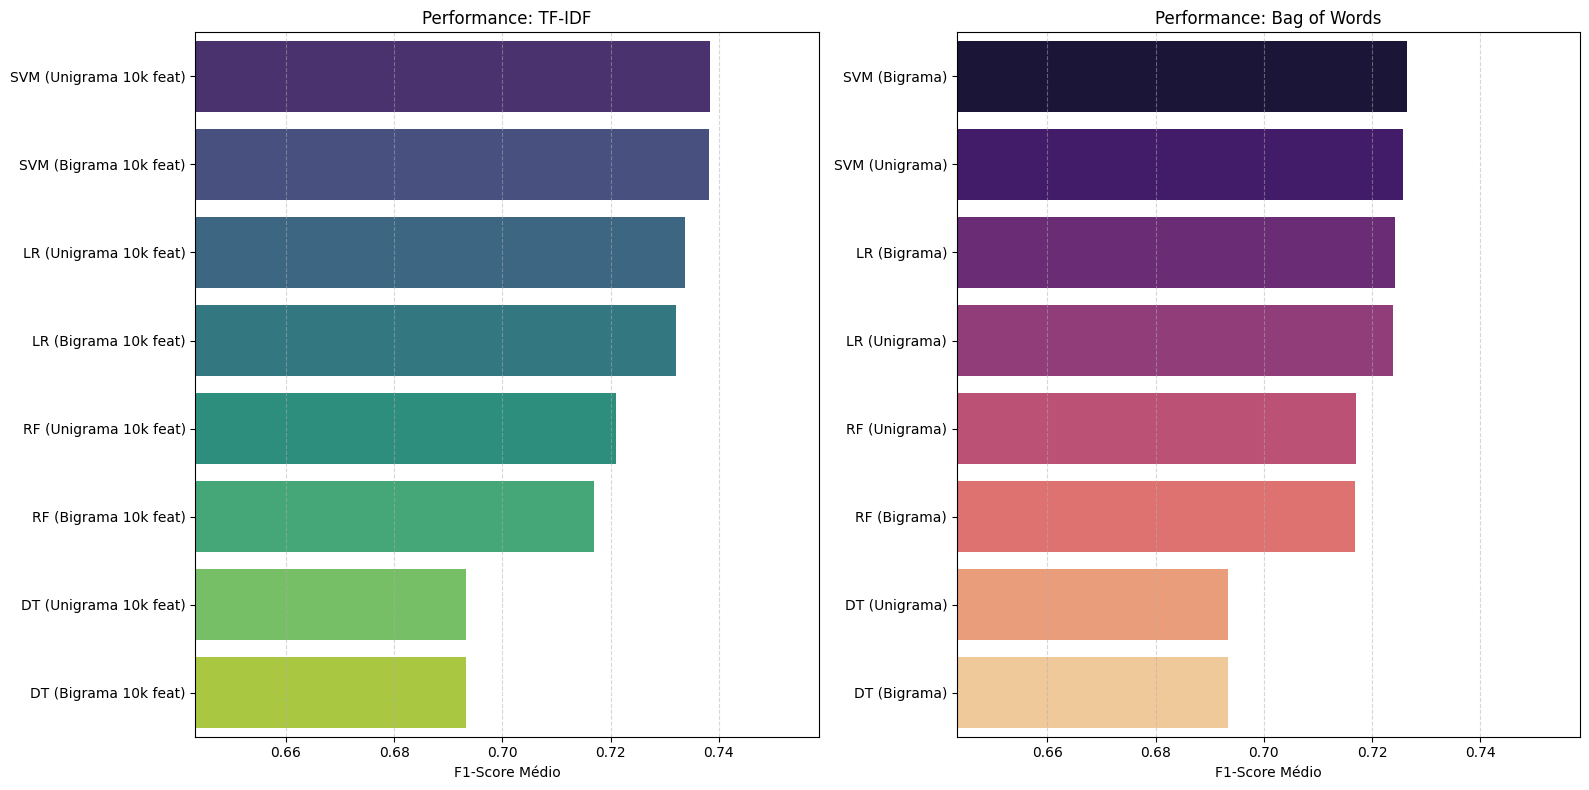

In [ ]:
df_ranking = pg.plot_ranking_experimentos(df_resultados)

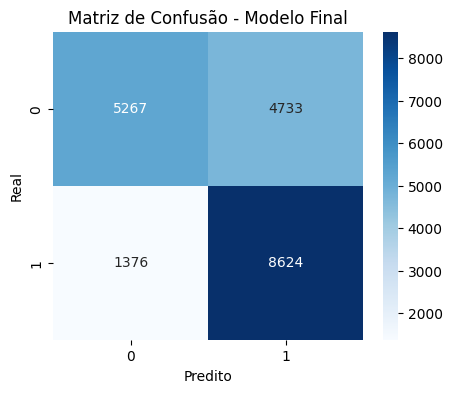

In [61]:
config_alvo = "TF-IDF | {'ngram_range': (1, 1), 'min_df': 2, 'sublinear_tf': False, 'max_features': 10000}"

pg.plot_matriz_por_tecnica_modelo(
    resultados_gerais, 
    tecnica="TF-IDF", 
    configuracao=config_alvo, 
    modelo="SVM"
)

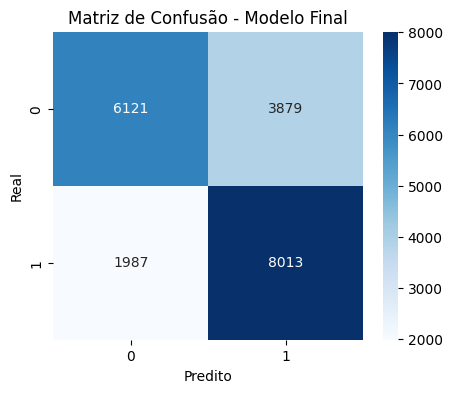

In [62]:
config_alvo = "TF-IDF | {'ngram_range': (1, 2), 'min_df': 2, 'sublinear_tf': True, 'max_features': 10000}"

pg.plot_matriz_por_tecnica_modelo(
    resultados_gerais, 
    tecnica="TF-IDF", 
    configuracao=config_alvo, 
    modelo="LR"
)

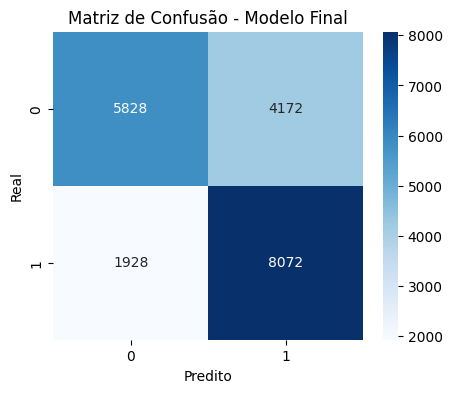

In [63]:
config_alvo = "Bag of Words | {'ngram_range': (1, 1), 'min_df': 5, 'max_df': 0.9}"

pg.plot_matriz_por_tecnica_modelo(
    resultados_gerais, 
    tecnica="Bag of Words", 
    configuracao=config_alvo, 
    modelo="SVM"
)


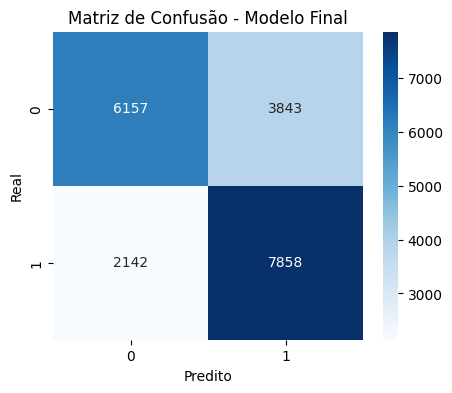

In [64]:
config_alvo = "Bag of Words | {'ngram_range': (1, 2), 'min_df': 5, 'max_df': 0.9}"

pg.plot_matriz_por_tecnica_modelo(
    resultados_gerais, 
    tecnica="Bag of Words", 
    configuracao=config_alvo, 
    modelo="LR"
)

Melhor Modelo Identificado: SVM (TF-IDF)
Configuração: TF-IDF | {'ngram_range': (1, 1), 'min_df': 2, 'sublinear_tf': False, 'max_features': 10000}


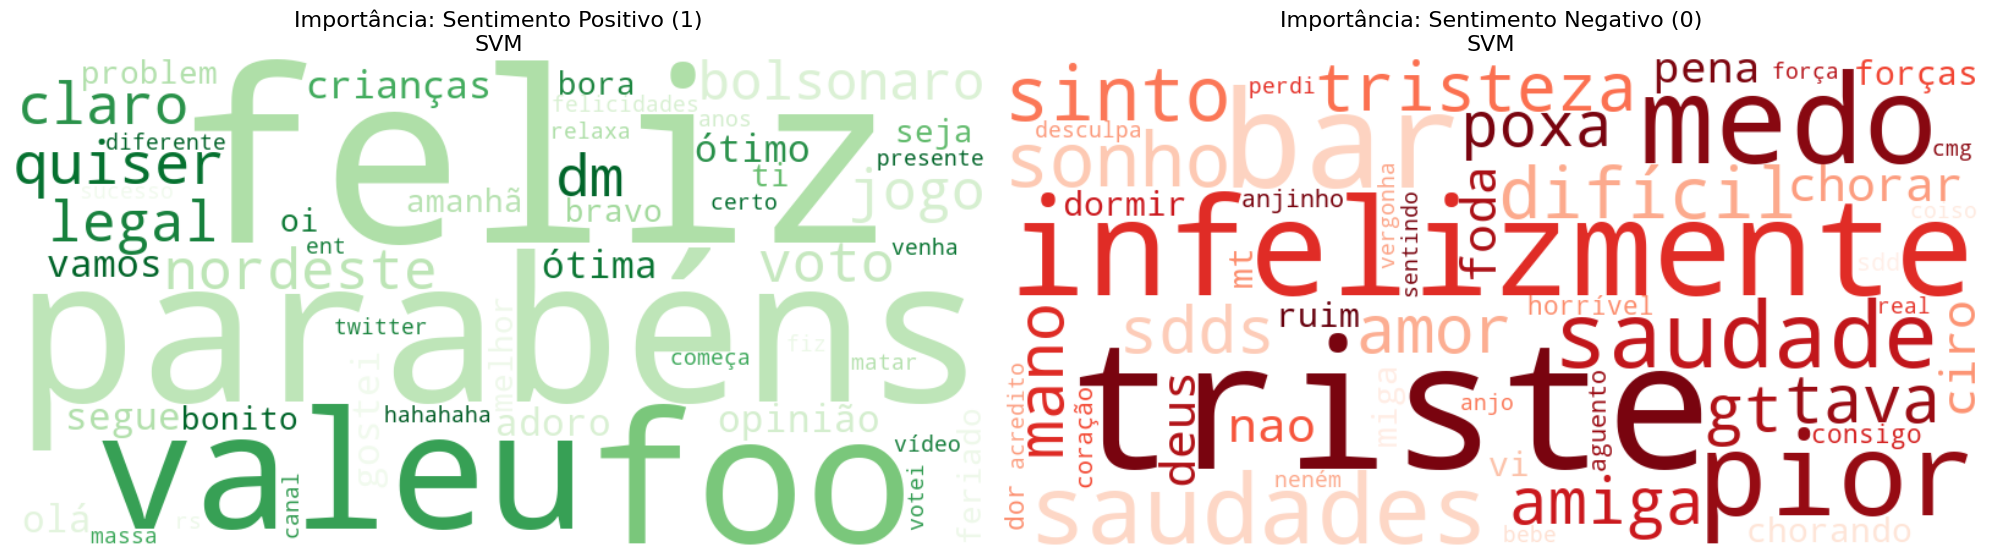

In [71]:
pg.plot_nuvem_melhor_modelo(resultados_gerais)